Let's write down the thirteen equations.

We also know that there are seven equations that when squared give a six-digit number, and that there are six equations that when cubed give a six-digit number. Since the equations are in sequential order, the cubes must come before the squares.

In [1]:
import itertools
import matplotlib.pyplot as plt
from collections.abc import Callable

In [9]:
## Numbers that if cubed give a six-digit number with no zeros
S1 = {x for x in range(47, 100) if '0' not in str(x * x * x)}

## Numbers that if squared give a six-digit number with no zeros
S2 = {x for x in range(317, 1000) if '0' not in str(x * x)}

## These must all give a result in S1
def eq01(*, B, E, **_):
    return B * E
def eq02(*, B, D, E, **_):
    return D - B * E
def eq03(*, A, C, F, **_):
    return A * (F + C)
def eq04(*, E, F, **_):
    return E * F
def eq05(*, B, C, F, **_):
    return C * (B + F)
def eq06(*, C, D, F, **_):
    return D - (F + C)

## These must all give a result in S2.
def eq07(*, A, C, D, **_):
    return C * D - A
def eq08(*, A, C, D, **_):
    return A * (D - C * A)
def eq09(*, A, B, C, E, F, **_):
    return B * (F * C + A - E)
def eq10(*, A, B, **_):
    return A * B * B
def eq11(*, B, D, E, F, **_):
    return E * (D - F) - B
def eq12(*, A, B, C, D, E, **_):
    return A * (D + E * (B + C))
def eq13(*, A, C, D, E, **_):
    return D * (A + C) - E


In [10]:
def get_values():
    for B, E in itertools.product(range(1, max(S1) + 1), repeat=2):
        # Equation 1 limits B and E so that they multiply to be a member of S1
        if (x01 := eq01(B=B, E=E)) in S1:
            # A ≤ 50 from Equation 3.  Equation 10 is quite limiting.
            for A in range(1, 50):
                if (x10 := eq10(A=A, B=B, E=E)) in S2:
                    # F's lower bound is comparing eq01 to eq04.
                    # F's upper bound is that F * E is in S1
                    for F in range(B, (100 // E) + 1):
                        if (x04 := eq04(A=A, B=B, E=E, F=F)) in S1 and x04 > x01:
                            # From Equation 5, C <= 50
                            for C in range(1, 51):
                                x03 = eq03(A=A, B=B, C=C, E=E, F=F)
                                if not (x03 in S1 and x01 < x03 < x04): continue
                                x05 = eq05(A=A, B=B, C=C, E=E, F=F)
                                if not (x05 in S1 and x04 < x05): continue
                                x09 = eq09(A=A, B=B, C=C, E=E, F=F)
                                if not (x09 in S2 and x09 < x10): continue
                                # eq2 limits D's values
                                for t in (x for x in S1 if x01 < x < x03):
                                    D = t + B * E
                                    equations: list[Callable] = [
                                        eq01, eq02, eq03, eq04, eq05, eq06,
                                        eq07, eq08, eq09, eq10, eq11, eq12, eq13]
                                    values = [eqn(A=A, B=B, C=C, D=D, E=E, F=F) for eqn in equations]
                                    okay = (all(x in S1 for x in values[:6]) and
                                            all(x in S2 for x in values[6:]) and
                                            all(x < y for x, y in itertools.pairwise(values)))
                                    if okay:
                                        yield {'A': A, 'B': B, 'C': C, 'D': D, 'E': E, 'F': F,
                                               'values': values}

results = list(get_values())
print(len(results))

1


In [11]:
values = results[0]['values']
cubes = [i * i * i for i in values[:6]]
squares = [i * i for i in values[6:]]
print(cubes)
print(squares)

[166375, 195112, 262144, 274625, 373248, 912673]
[112225, 163216, 174724, 234256, 239121, 535824, 617796]


The six rows and six columns use the same digits.
The excess of digits that are in the squares that aren't in the cubes must precisely be the digits of the entry that form the diagonal.

In [14]:
from collections import Counter

square_digits = Counter(letter for square in squares for letter in str(square))
cube_digits = Counter(letter for cube in cubes for letter in str(cube))
print('digit squares cubes delta')
for digit in range(0, 10):
    sd = square_digits[str(digit)]
    cd = cube_digits[str(digit)]
    print(f'  {digit} {sd:6d} {cd:5d} {sd - cd:5}')

digit squares cubes delta
  0      0     0     0
  1      8     6     2
  2     10     7     3
  3      4     4     0
  4      4     4     0
  5      4     3     1
  6      5     5     0
  7      4     4     0
  8      1     1     0
  9      2     2     0


We have that the diagonal must contain two 1's, three 2's, and one 5. The only down with those digits  is 112225 and it must be entered on the diagonal in precisely that order.

| &nbsp; | &nbsp; | &nbsp; | &nbsp; | &nbsp; | &nbsp; |
|:------:|:------:|:------:|:------:|:------:|:------:|
|   1    | &nbsp; | &nbsp; | &nbsp; | &nbsp; | &nbsp; |
| &nbsp; |   1    | &nbsp; | &nbsp; | &nbsp; | &nbsp; |
| &nbsp; | &nbsp; |   2    | &nbsp; | &nbsp; | &nbsp; |
| &nbsp; | &nbsp; | &nbsp; |   2    | &nbsp; | &nbsp; |
| &nbsp; | &nbsp; | &nbsp; | &nbsp; |   2    | &nbsp; |
| &nbsp; | &nbsp; | &nbsp; | &nbsp; | &nbsp; |   5    |


At this point filling in the rows is easy.
* Row 5 must contain `274265`
* Row 4 must contain `373248`
* Row 2 must contain `912673`
* Row 3 must contain `262144`
* Row 6 must contain `166375`
* Row 1 must contain `195112`

| &nbsp; | &nbsp; | &nbsp; | &nbsp; | &nbsp; | &nbsp; |
|:------:|:------:|:------:|:------:|:------:|:------:|
|   1    |   9    |   5    |   1    |   1    |   2    |
|   9    |   1    |   2    |   6    |   7    |   3    |
|   2    |   6    |   2    |   1    |   4    |   4    |
|   3    |   7    |   3    |   2    |   4    |   8    |
|   2    |   7    |   4    |   6    |   2    |   5    |
|   1    |   6    |   6    |   3    |   7    |   5    |

We can now check that all the columns work.

* `163216` is in Column 4
* `174724` is in Column 5
* `234256`,is in Column 3
* `239121` is in Column 1
* `535824` is in Column 6
* `617796` is in Column 2

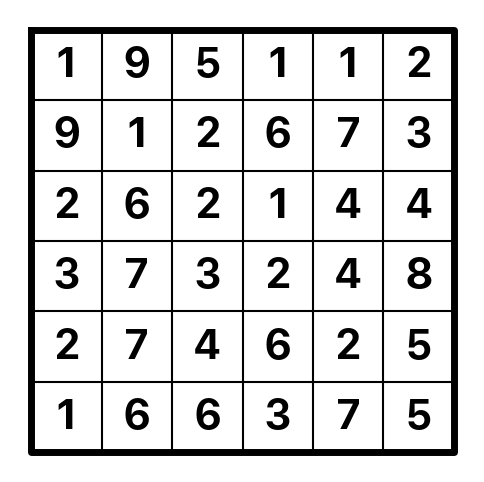

In [15]:
RESULT = """
1 9 5 1 1 2
9 1 2 6 7 3
2 6 2 1 4 4
3 7 3 2 4 8
2 7 4 6 2 5
1 6 6 3 7 5"""

digits = [x for x in RESULT if '0' <= x <= '9']
squares = itertools.product(range(1, 7), repeat=2)
grid = dict(zip(squares, digits))
# draw_grid(max_row=7, max_column=7, location_to_entry=grid)

_, axes = plt.subplots(1, 1, figsize=(6, 6), dpi=100)
# set (1,1) as the top-left corner, and (max_column, max_row) as the bottom right.
axes.axis((1, 7, 7, 1))
axes.axis('equal')
axes.axis('off')

# Draw the grid
axes.plot([1, 1, 7, 7, 1], [1, 7, 7, 1, 1], 'black', linewidth=5)
for i in range(2, 7):
    axes.plot([i, i], [1, 7], 'black')
    axes.plot([1, 7], [i, i], 'black')

# Fill in the squares
for (row, column), entry in grid.items():
    axes.text(column + 1 / 2, row + 1 / 2, entry,
              color='black',
              fontsize=30, fontweight='bold',
              fontfamily="SF Pro Text",
              va='center', ha='center')